# 6G Indoor Radio Map: GCN/GAT vs. IDW/Kriging Sweep

Built from RadioGAT-inspired scaffolding, adapted to the **DeepMIMO** indoor mmWave ray-tracing dataset.

Pipeline:
1. Install dependencies
2. Load an indoor DeepMIMO scenario (point cloud + RSS + environment features)
3. Build k-NN / Delaunay graphs
4. Define GCN and GAT models
5. Define IDW and Kriging baselines
6. Run a dense/sparse x topology x model sweep

**Before running the full sweep:** run the "list indoor scenarios" cell first, inspect the printed names, and set `SCENARIO_NAME` to a real one — the online catalog changes over time, so nothing is hardcoded.


## 1. Setup

In [1]:
import sys
print(sys.executable)

/home/praaneshnair/random/prism/.venv/bin/python


In [12]:
import sys

!uv pip install --python {sys.executable} deepmimo torch torch_geometric scikit-learn scipy matplotlib pykrige pandas


Resolved 66 packages in 600ms                                        
Installed 1 package in 276ms                                
 + pandas==3.0.5


## 2. Data loading — DeepMIMO indoor scenario

Loads an indoor DeepMIMO scenario and turns it into the point-cloud format the rest of
the pipeline (graph construction, GCN/GAT, baselines) expects:

- `positions`: `(N, 3)` array of rx `(x, y, z)`
- `rss`: `(N,)` received power in dBm for one tx
- `env_feats`: `(N, F)` per-point environment features (LOS flag, distance to tx, etc.)


In [3]:
import numpy as np
import deepmimo as dm

def list_indoor_scenarios():
    """Search the live DeepMIMO catalog for indoor scenarios. Run this first
    and pick a name from the printed list -- don't hardcode a slug, the
    catalog changes."""
    results = dm.search({"environment": "indoor"})
    for r in results:
        print(r)
    return results

def load_scenario(scenario_name: str, tx_index: int = 0, max_points: int | None = 5000, seed: int = 0):
    dm.download(scenario_name)
    dataset = dm.load(scenario_name)

    # rx positions (N, 3)
    positions = np.asarray(dataset.rx_pos)

    # channel / power: compute channels then take received power for one tx
    channels = dataset.compute_channels()          # [n_ue, n_rx_ant, n_tx_ant, n_sub]
    power_lin = np.mean(np.abs(channels[:, :, tx_index, :]) ** 2, axis=(1, 2))
    rss_dbm = 10 * np.log10(power_lin + 1e-15)

    # environment features: LOS/NLOS flag + distance to serving tx is always
    # available; add material/height fields here if your chosen scenario has them
    tx_pos = np.asarray(dataset.tx_pos[tx_index])
    dist_to_tx = np.linalg.norm(positions - tx_pos, axis=1)
    los_flag = np.asarray(dataset.los).astype(float) if hasattr(dataset, "los") else np.ones(len(positions))

    env_feats = np.stack([dist_to_tx, los_flag], axis=1)

    # DeepMIMO scenarios can have 10^5+ rx points. Kriging is roughly O(N^3)
    # and GNN training on a huge graph is slow on CPU with nothing printed --
    # both look "stuck" but are just very slow. Subsample unless disabled.
    n_points = len(positions)
    if max_points is not None and n_points > max_points:
        rng = np.random.default_rng(seed)
        keep = rng.choice(n_points, size=max_points, replace=False)
        positions, rss_dbm, env_feats = positions[keep], rss_dbm[keep], env_feats[keep]
        print(f"Subsampled {scenario_name}: {n_points} -> {max_points} rx points.")

    return positions, rss_dbm, env_feats

Install with: pip install 'deepmimo[aodt]'


### 2a. List live indoor scenarios (run this first)

In [4]:
list_indoor_scenarios()


i1_2p5
i2_28b


['i1_2p5', 'i2_28b']

### 2b. Pick a scenario name from the list above, then load it

In [5]:
SCENARIO_NAME = "i2_28b"

pos, rss, feats = load_scenario(SCENARIO_NAME)
print(pos.shape, rss.shape, feats.shape)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 140901)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.52it/s]

Subsampled i2_28b: 140901 -> 5000 rx points.
(5000, 3) (5000,) (5000, 2)


## 3. Graph construction — k-NN and Delaunay

Two interchangeable edge-construction functions, both returning an `edge_index`
of shape `(2, num_edges)` in the format `torch_geometric` expects.


In [6]:
from scipy.spatial import Delaunay
from sklearn.neighbors import kneighbors_graph

def knn_graph(positions: np.ndarray, k: int = 6):
    adj = kneighbors_graph(positions, n_neighbors=k, mode="connectivity", include_self=False)
    adj = adj.maximum(adj.T)  # symmetrize
    coo = adj.tocoo()
    edge_index = np.vstack([coo.row, coo.col])
    return edge_index

def delaunay_graph(positions: np.ndarray):
    # Delaunay works on the 2D (x, y) footprint; z is usually near-constant per floor
    tri = Delaunay(positions[:, :2])
    edges = set()
    for simplex in tri.simplices:
        for i in range(3):
            a, b = simplex[i], simplex[(i + 1) % 3]
            edges.add((a, b))
            edges.add((b, a))
    edge_index = np.array(list(edges)).T
    return edge_index

BUILDERS = {"knn": knn_graph, "delaunay": delaunay_graph}


## 4. Models — GCN and GAT

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv

class GCN(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3):
        super().__init__()
        dims = [in_channels] + [hidden] * (layers - 1) + [out_channels]
        self.convs = nn.ModuleList([GCNConv(dims[i], dims[i + 1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
        return x

class GAT(nn.Module):
    def __init__(self, in_channels, hidden=64, out_channels=1, layers=3, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden, heads=heads, concat=True))
        for _ in range(layers - 2):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, concat=True))
        self.convs.append(GATConv(hidden * heads, out_channels, heads=1, concat=False))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.elu(x)
        return x


/home/praaneshnair/random/prism/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 5. Baselines — IDW and Kriging

In [8]:
from pykrige.ok import OrdinaryKriging

def idw_predict(train_pos, train_val, test_pos, power=2, eps=1e-9):
    preds = np.zeros(len(test_pos))
    for i, p in enumerate(test_pos):
        d = np.linalg.norm(train_pos - p, axis=1) + eps
        w = 1.0 / (d ** power)
        preds[i] = np.sum(w * train_val) / np.sum(w)
    return preds

def kriging_predict(train_pos, train_val, test_pos):
    ok = OrdinaryKriging(train_pos[:, 0], train_pos[:, 1], train_val, variogram_model="spherical")
    preds, _ = ok.execute("points", test_pos[:, 0], test_pos[:, 1])
    return np.asarray(preds)


## 6. Training loop + dense/sparse x topology x model sweep

Runs GCN and GAT over both graph topologies, plus IDW and Kriging baselines,
across a set of labeled-point densities (e.g. sparse 30-50 pts vs. dense 200+ pts).


In [9]:
from sklearn.metrics import mean_squared_error

def make_split(n_points, n_labeled, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n_points)
    return idx[:n_labeled], idx[n_labeled:]

def run_gnn(model_cls, positions, feats, rss, edge_index, train_idx, test_idx, epochs=200, lr=0.005, device="cpu"):
    x = torch.tensor(np.hstack([positions, feats]), dtype=torch.float32).to(device)
    y = torch.tensor(rss, dtype=torch.float32).unsqueeze(1).to(device)
    ei = torch.tensor(edge_index, dtype=torch.long).to(device)
    mask = torch.zeros(len(rss), dtype=torch.bool)
    mask[train_idx] = True
    mask = mask.to(device)

    model = model_cls(in_channels=x.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(x, ei)
        loss = loss_fn(out[mask], y[mask])
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(x, ei).cpu().numpy().squeeze()
    rmse = float(np.sqrt(mean_squared_error(rss[test_idx], pred[test_idx])))
    return rmse

def sweep(scenario_name, densities=(30, 50, 200), topologies=("knn", "delaunay")):
    positions, rss, feats = load_scenario(scenario_name)
    results = []

    for n_labeled in densities:
        train_idx, test_idx = make_split(len(positions), n_labeled)

        for topo in topologies:
            edge_index = BUILDERS[topo](positions)

            for name, model_cls in [("GCN", GCN), ("GAT", GAT)]:
                rmse = run_gnn(model_cls, positions, feats, rss, edge_index, train_idx, test_idx)
                results.append({"density": n_labeled, "topology": topo, "model": name, "rmse": rmse})

        idw_pred = idw_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "IDW",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], idw_pred)))})

        krig_pred = kriging_predict(positions[train_idx], rss[train_idx], positions[test_idx])
        results.append({"density": n_labeled, "topology": "-", "model": "Kriging",
                         "rmse": float(np.sqrt(mean_squared_error(rss[test_idx], krig_pred)))})

    return results


### 6a. Run the sweep

Uses the `SCENARIO_NAME` you set in cell 2b.

In [10]:
results = sweep(SCENARIO_NAME)
for row in results:
    print(row)


Scenario "i2_28b" already exists in /home/praaneshnair/random/prism/deepmimo_scenarios
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 140901)


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.01it/s]


Subsampled i2_28b: 140901 -> 5000 rx points.
{'density': 30, 'topology': 'knn', 'model': 'GCN', 'rmse': 11.241363940582518}
{'density': 30, 'topology': 'knn', 'model': 'GAT', 'rmse': 6.074151552080069}
{'density': 30, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 16.30194241236349}
{'density': 30, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 6.096288533748936}
{'density': 30, 'topology': '-', 'model': 'IDW', 'rmse': 6.102183462254298}
{'density': 30, 'topology': '-', 'model': 'Kriging', 'rmse': 5.878807635666456}
{'density': 50, 'topology': 'knn', 'model': 'GCN', 'rmse': 10.748229834725256}
{'density': 50, 'topology': 'knn', 'model': 'GAT', 'rmse': 6.109083085756948}
{'density': 50, 'topology': 'delaunay', 'model': 'GCN', 'rmse': 13.97639655435303}
{'density': 50, 'topology': 'delaunay', 'model': 'GAT', 'rmse': 5.99554977683155}
{'density': 50, 'topology': '-', 'model': 'IDW', 'rmse': 6.10082202615225}
{'density': 50, 'topology': '-', 'model': 'Kriging', 'rmse': 5.8531997606330535

### 6b. (Optional) Tabulate and plot results

,density,topology,model,rmse
0,30,knn,GCN,11.241364
1,30,knn,GAT,6.074152
2,30,delaunay,GCN,16.301942
3,30,delaunay,GAT,6.096289
4,30,-,IDW,6.102183
5,30,-,Kriging,5.878808
6,50,knn,GCN,10.748230
7,50,knn,GAT,6.109083
8,50,delaunay,GCN,13.976397
9,50,delaunay,GAT,5.995550


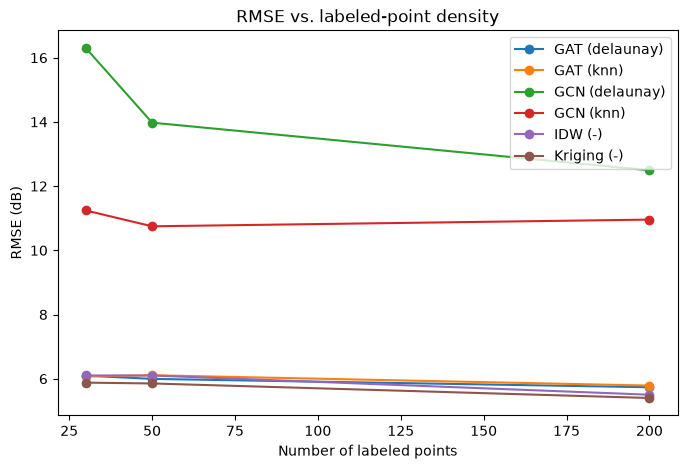

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(8, 5))
for (model, topo), grp in df.groupby(["model", "topology"]):
    grp = grp.sort_values("density")
    ax.plot(grp["density"], grp["rmse"], marker="o", label=f"{model} ({topo})")
ax.set_xlabel("Number of labeled points")
ax.set_ylabel("RMSE (dB)")
ax.set_title("RMSE vs. labeled-point density")
ax.legend()
plt.show()
